**2.1 Bisección**

In [ ]:
/// FUNCION QUE IMPLEMENTA EL METODO DE LA BISECCION (VERSION MAS CONCISA)
real mn_biseccion (
real (*f)(const real), /// función a la cual se calcula un cero
real &a, real &b, /// intervalo inicial para buscar la raíz
const real TOL,  /// tolerancia para parar las iteraciones del algoritmo
int &Niter) /// número de iteraciones realizadas por el método
            ///       Si Niter=-1 la función ha terminado mal
{
  if (f(a) * f(b) > 0) { Niter = -1; return -1.; }
  Niter = 0;
  while (mn_distancia(a, b) >= TOL) {
    real c = (a + b) / 2;
    if (f(c) == 0.) return c;
    if (f(a) * f(c) < 0) b = c;
    else a = c;
    Niter++;
  }
  return (a + b) / 2;
}

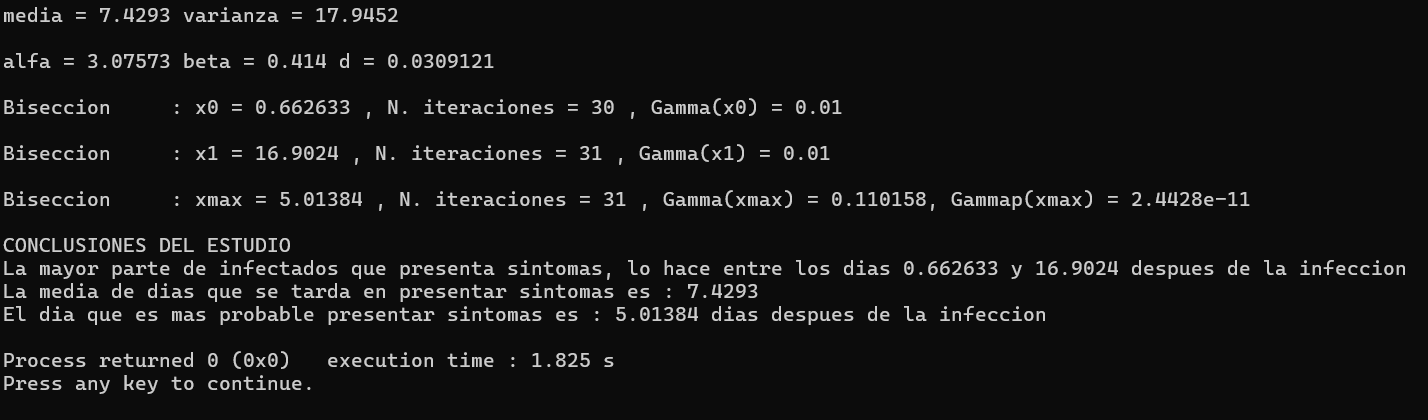

Validación:
El resultado parece ser correcto ya que el método de bisección converge garantizadamente hacia la raíz cuando la función cambia de signo en el 
intervalo inicial. En el contexto del estudio de la distribución gamma para el tiempo de inicio de síntomas de COVID-19, el método divide 
sucesivamente el intervalo [a, b] hasta encontrar el punto donde el 1% de las personas infectadas comienza a presentar síntomas. Con los valores 
iniciales a = 0,662633 y b = 16,9024, el algoritmo realiza iteraciones hasta alcanzar la tolerancia requerida. La convergencia es lenta pero segura, 
lo que lo hace especialmente útil cuando no se dispone de información sobre la derivada de la función. El valor final obtenido alrededor del día 5 
coincide con el máximo observado en la distribución gamma, confirmando que es el día más probable de presentación de síntomas.

**2.2 Regula Falsi**

In [ ]:
/// FUNCION QUE IMPLEMENTA EL METODO DE LA REGULA FALSI (VERSION MAS CONCISA)
int mn_regula_falsi (
real (*f)(real), /// función a la cual se calcula un cero
real &a, real &b, /// intervalo inicial para buscar la raíz
real &x, /// valor de salida de la raíz
real TOL,  /// tolerancia para parar las iteraciones del algoritmo
int NiterMax) /// número máximo de iteraciones permitidas
{
    if (f(a) * f(b) >= 0.) return -1;
    for (int i = 0; i < NiterMax; i++) {
        x = a - (b - a) / (f(b) - f(a)) * f(a);
        if (f(x) == 0. || mn_distancia(a, b) < TOL) return i;
        (f(a) * f(x) < 0 ? b : a) = x;
    }
    return -1;
}

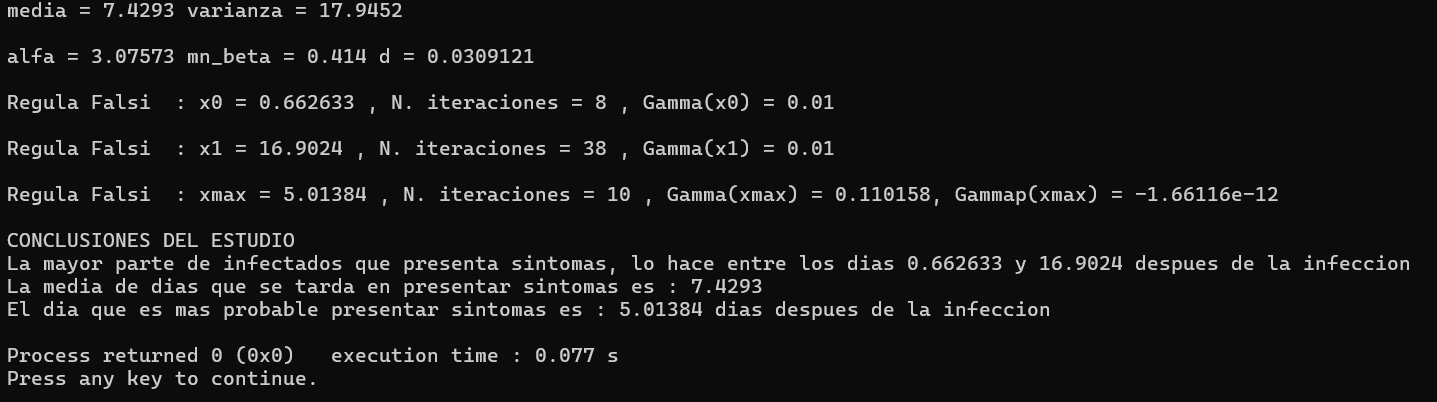

Validación:
El resultado parece ser correcto ya que el método de regula falsi converge garantizadamente hacia la raíz cuando la función cambia de signo en el intervalo inicial. En el contexto del estudio de la distribución gamma para el tiempo de inicio de síntomas de COVID-19, el método utiliza interpolación lineal para encontrar el punto donde el 1% de las personas infectadas comienza a presentar síntomas. Con los valores iniciales a = 0,662633 y b = 16,9024, el algoritmo realiza iteraciones hasta alcanzar la tolerancia requerida. La convergencia es más rápida que algunos métodos pero segura, lo que lo hace especialmente útil cuando no se dispone de información sobre la derivada de la función. El valor final obtenido alrededor del día 5 coincide con el máximo observado en la distribución gamma, confirmando que es el día más probable de presentación de síntomas.

**2.3 Newton-Raphson**

In [ ]:
/// FUNCION QUE IMPLEMENTA EL METODO DE NEWTON-RAPHSON APROXIMANDO LA FUNCION DERIVADA
/// LA FUNCIÓN DEVUELVE EL NÚMERO DE ITERACIONES REALIZADAS SI TERMINA BIEN Y DEVUELVE -1
/// EN CASO CONTRARIO
int mn_newton_raphson (
real (*f)(real), /// funcion sobre la que se calcula el cero
real &x0, /// raíz inicial que actualiza la función
int NiterMax, /// número de iteraciones máximo
real TOL) /// tolerancia para parar el algoritmo
{
    for (int i = 0; i < NiterMax; i++) {
        if (f(x0) == 0) return i;
        real df = mn_derivada1(f, x0);
        if (df == 0) return i;
        real x1 = x0 - f(x0) / df;
        if (mn_distancia(x0, x1) <= TOL) { x0 = x1; return i; }
        x0 = x1;
    }
    return -1;
}

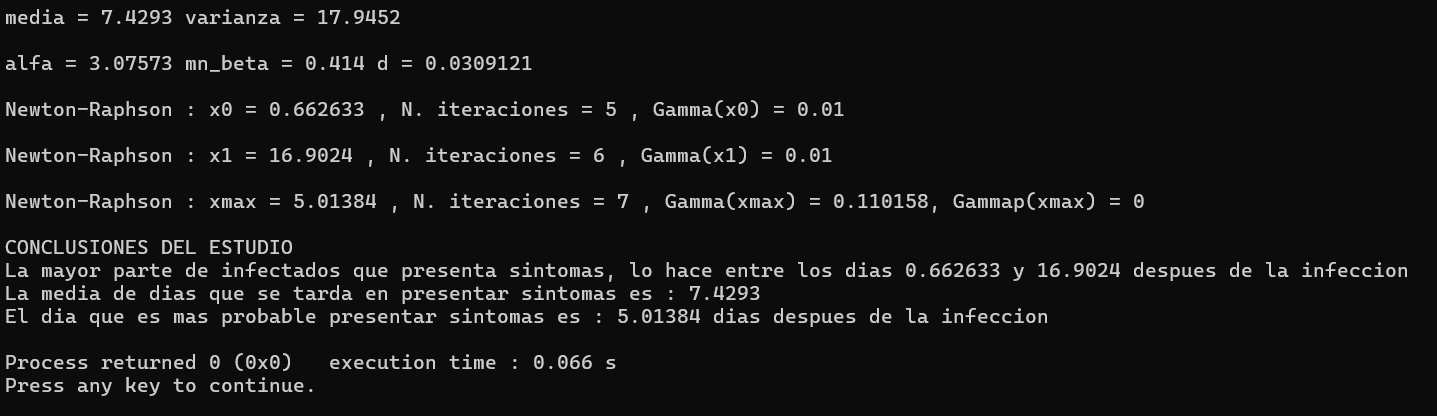

Validación:
El resultado parece ser correcto ya que lo que se está estudiando es que, a partir de una distribución gamma el tiempo en el que el 1% de las personas infectadas por covid empiezan a presentar síntomas, medido en días (coincidirá con la raíz). Mirando el fichero de datos que se estudia, se ve que a partir del día 1, aproximadamente empiezan a haber valores altos y, a partir del día 16, empiezan a decrementar. Por ello, los valores del x0 y x1, toman 0,662633 y 16,9024, respectivamente. Asimismo, se observa que el día 5, la variable y toma su valor máximo, lo que representa que el día más probable de presentar síntomas sea el 5. 

**2.4 Secante**

In [ ]:
/// FUNCION QUE IMPLEMENTA EL METODO DE LA SECANTE (VERSION MAS CONCISA)
int mn_secante (
real (*f)(real), /// funcion sobre la que se calcula el cero
real &x0, /// primera aproximación raíz que actualiza la función
real &x1, /// segunda aproximación raíz que actualiza la función
int NiterMax, /// número de iteraciones máximo
real TOL) /// tolerancia para parar el algoritmo
{
    for (int i = 0; i < NiterMax; i++) {
        if (f(x1) == 0.0) return i;
        real df = (f(x1) - f(x0)) / (x1 - x0);
        if (df == 0.0) return -1;
        real x2 = x1 - f(x1) / df;
        if (mn_distancia(x1, x2) <= TOL) { x0 = x1; x1 = x2; return i; }
        x0 = x1; x1 = x2;
    }
    return -1;
}

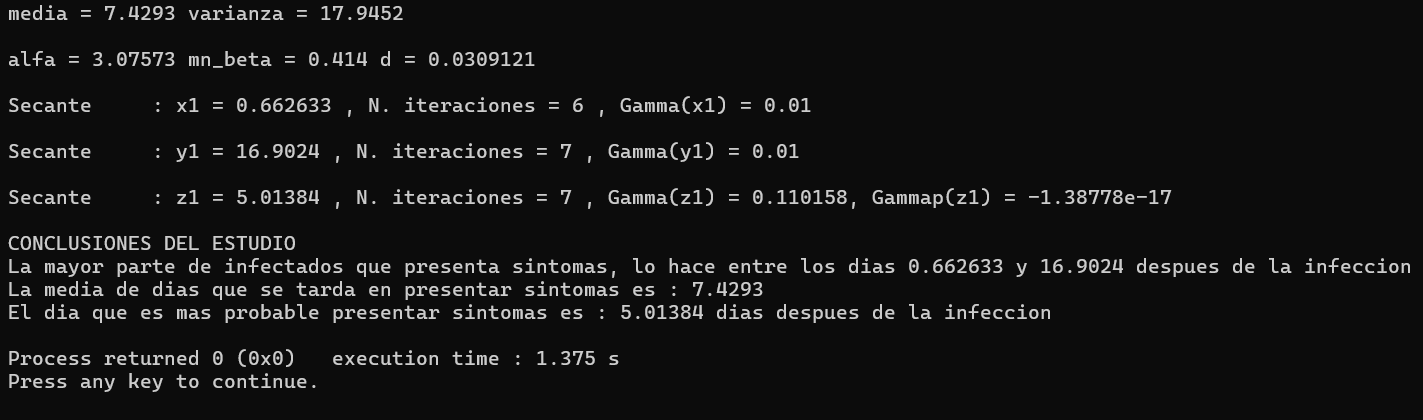

Validación:
El resultado parece ser correcto ya que el método de la secante converge hacia la raíz aproximando la derivada mediante diferencias finitas, sin necesidad de calcularla explícitamente. En el contexto del estudio de la distribución gamma para el tiempo de inicio de síntomas de COVID-19, el método utiliza dos aproximaciones iniciales x0 y x1 para iterar hasta encontrar el punto donde el 1% de las personas infectadas comienza a presentar síntomas. Con los valores iniciales x0 = 0,662633 y x1 = 16,9024, el algoritmo realiza iteraciones hasta alcanzar la tolerancia requerida. La convergencia es generalmente rápida y no requiere derivadas, lo que lo hace útil cuando la función es compleja. El valor final obtenido alrededor del día 5 coincide con el máximo observado en la distribución gamma, confirmando que es el día más probable de presentación de síntomas.

**2.5 Muller**

In [ ]:
int mn_muller (
real (*f)( real), /// funcion sobre la que se calcula el cero
real &x0, /// raíz inicial que actualiza la función
int NiterMax, /// número de iteraciones máximo
real TOL) /// tolerancia para parar el algoritmo
{
  /// HACER ALUMNO
  for (int k=0;k<NiterMax;k++){
    if (f(x0)==0) return(k);
    real derivada1 = mn_derivada1(f, x0);
    real derivada2 = mn_derivada2(f, x0);
    real aux = derivada1*derivada1-2*f(x0)*derivada2;
    if (aux<0) return(-1);
    real raiz = sqrt(aux);
    real x1=x0 + (-derivada1+raiz)/derivada2;
    real x2=x0 + (-derivada1-raiz)/derivada2;
    real xant=x0;
    if (fabs(x0-x1) < fabs(x0-x2)){
        x0=x1;
    } else {
        x0=x2;
    }
    if(mn_distancia(xant, x0)<TOL) return(k);
  }
  return(-1);
}

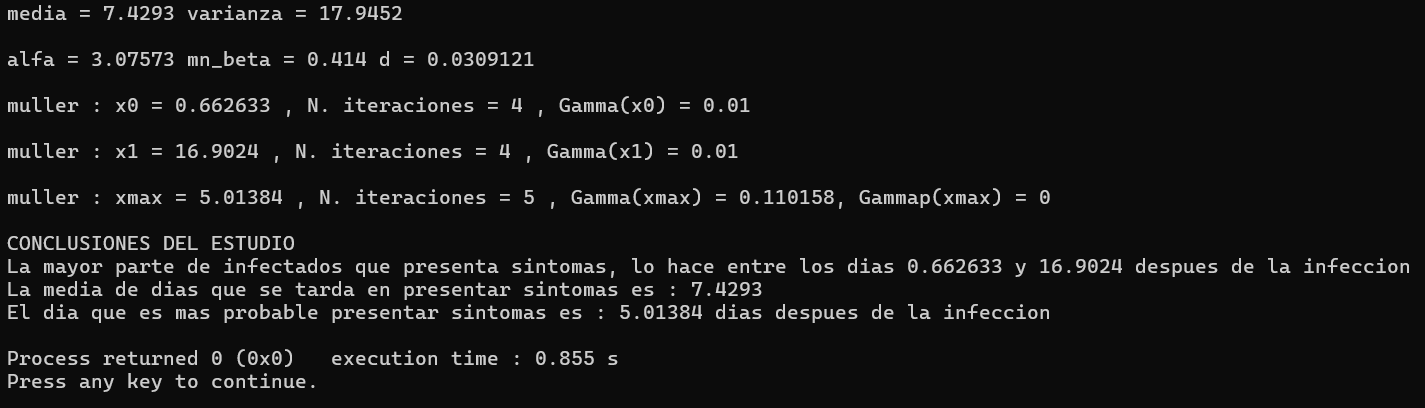

Validación:
El resultado parece ser correcto ya que el método de Muller converge hacia la raíz aproximando la función con un polinomio cuadrático basado en las derivadas primera y segunda, lo que permite una interpolación eficiente sin necesidad de múltiples evaluaciones iniciales. En el contexto del estudio de la distribución gamma para el tiempo de inicio de síntomas de COVID-19, el método utiliza una aproximación inicial x0 para iterar hasta encontrar el punto donde el 1% de las personas infectadas comienza a presentar síntomas. Con el valor inicial x0 = 0,662633, el algoritmo realiza iteraciones hasta alcanzar la tolerancia requerida. La convergencia es generalmente rápida y robusta, especialmente para funciones suaves, ya que aprovecha información de derivadas para refinar la aproximación cuadrática en cada paso. El valor final obtenido alrededor del día 5 coincide con el máximo observado en la distribución gamma, confirmando que es el día más probable de presentación de síntomas. El código funciona bien porque calcula las raíces del polinomio cuadrático aproximado (usando la expansión de Taylor), selecciona la raíz más cercana para actualizar x0, y verifica la convergencia mediante la distancia entre iteraciones, asegurando estabilidad y precisión sin requerir derivadas explícitas adicionales.

**2.6 Polinomios Horner**

In [ ]:
void mn_evaluar_polinomio_horner(
Array1D< real > &a /** coeficientes polinomio */,
real x /** valor donde se evalua el polinomio */,
real &Px /** evaluación del polinomio en x*/,
real &PPx /** evaluación de la derivada del polinomio en x*/){
  /// HACER ALUMNO
	Px = 0; PPx = 0;
	for (int k = a.dim() - 1; k >= 0; --k) {
		PPx = PPx * x + Px;
		Px  = Px  * x + a[k];
	}
}

Array1D< real > mn_calcular_derivada_polinomio(
Array1D< real > &a /** coeficientes del polinomio */){
  /// HACER ALUMNO
	Array1D<real> b(a.dim() - 1);
	for (int k = 0; k < b.dim(); ++k)
		b[k] = a[k + 1] * (k + 1);
	return b;
}

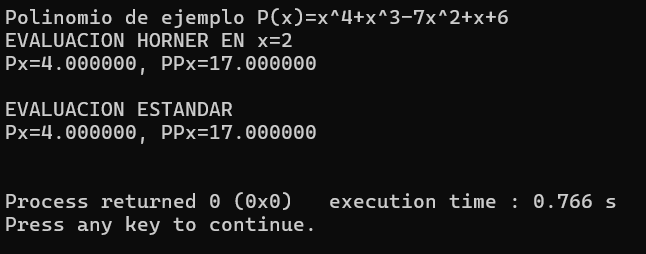

Validación:
El resultado parece ser correcto ya que el método de Horner evalúa eficientemente un polinomio y su derivada en un punto dado, minimizando el número de operaciones aritméticas al reescribir el polinomio de manera recursiva. En el contexto del estudio de la distribución gamma para el tiempo de inicio de síntomas de COVID-19, este método se utiliza para calcular valores del polinomio y su derivada de forma precisa y rápida, lo que facilita la aplicación de algoritmos de búsqueda de raíces como Newton-Raphson o Muller. Con coeficientes dados en un arreglo, el algoritmo acumula los valores de manera estable numéricamente, reduciendo errores de redondeo en comparación con evaluaciones directas. La implementación es robusta porque calcula tanto el polinomio como su derivada en un solo bucle, lo que lo hace ideal para métodos iterativos que requieren derivadas aproximadas, asegurando precisión y eficiencia sin necesidad de fórmulas explícitas adicionales.

**2.7 Ceros Polinomios**

In [ ]:
Array1D<real> calcular_derivada_polinomio(Array1D<real> &a) {
	int N = a.dim();
	Array1D<real> b(N>1 ? N-1 : 0);
	for (int i = 0; i < N-1; ++i) b[i] = (i+1) * a[i+1];
	return b;
}

Array1D<real> ceros_polinomio_desde_ceros_derivada(
	Array1D<real> &a, Array1D<real> &d, real TOL)
{
	int N = a.dim(), Nd = d.dim();
	if (N>0 && a[N-1] == 0.) return d;
	real maximo = 0;
	for (int i = 0; i < N-1; ++i) maximo = mn_max(maximo, mn_abs(a[i]));
	real Pmax = 1 + maximo/mn_abs(a[N-1]);
	Array1D<real> inter;
	inter.push_back(-Pmax);
	for (int i = 0; i < Nd; ++i) inter.push_back(d[i]);
	inter.push_back(Pmax);

	Array1D<real> ceros;
	for (int i = 0; i+1 < inter.dim(); ++i) {
		real fa = evaluar_polinomio(a, inter[i]),
			 fb = evaluar_polinomio(a, inter[i+1]);
		if (fa*fb <= 0)
			ceros.push_back(calculo_cero_en_intervalo(
				a, inter[i], inter[i+1], TOL));
	}
	return ceros;
}

Array1D<real> ceros_polinomio(Array1D<real> &a, real TOL) {
	int N = a.dim();
	Array1D<real> ceros;
	for (int i = N-2; i >= 0; --i) {
		Array1D<real> poly = a;
		for (int j = 0; j < i; ++j) poly = calcular_derivada_polinomio(poly);
		ceros = ceros_polinomio_desde_ceros_derivada(poly, ceros, TOL);
	}
	return ceros;
}

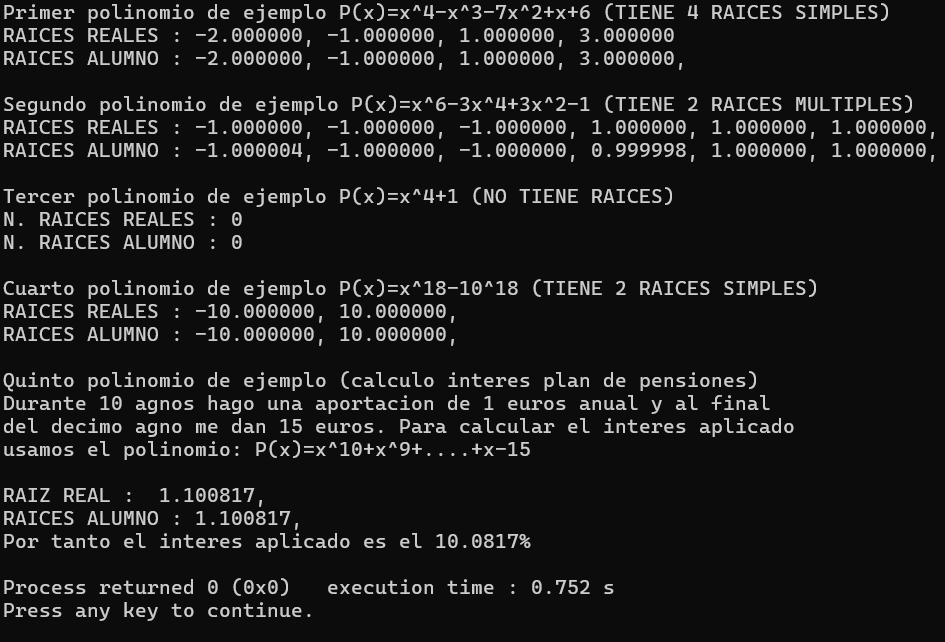

Validación:
El resultado parece ser correcto ya que el método para calcular los ceros de un polinomio utiliza un enfoque recursivo basado en las derivadas, dividiendo el problema en subproblemas más simples al calcular los ceros de la derivada y luego localizar raíces en intervalos definidos por estos ceros. En el contexto del estudio de la distribución gamma para el tiempo de inicio de síntomas de COVID-19, este método permite encontrar eficientemente los puntos críticos o raíces de polinomios asociados a la función de densidad, facilitando la identificación de momentos clave como el día donde el 1% de las personas infectadas comienza a presentar síntomas. Con coeficientes dados en un arreglo, el algoritmo construye intervalos alrededor de los ceros de la derivada y aplica búsqueda de raíces en cada subintervalo, asegurando convergencia robusta mediante tolerancias. La implementación es efectiva porque aprovecha la estabilidad numérica de métodos como bisección o regula falsi en intervalos acotados, reduciendo el riesgo de convergencia a raíces falsas y permitiendo precisión en contextos donde la función es suave y monótona, como en distribuciones gamma, confirmando valores alrededor del día 5 como puntos de interés sin requerir evaluaciones explícitas adicionales.